In [1]:
# [iris from csv file]<https://machinelearninghd.com/iris-dataset-uci-machine-learning-repository-project/>

In [2]:
import numpy as np
import pandas as pd 
from pandas import Series, DataFrame
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# Import Data

# url = 'https://raw.githubusercontent.com/Sketchjar/MachineLearningHD/main/iris.csv'
# df = load_iris(url)
iris = pd.read_csv('iris.csv')
iris.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
# Add column 1. PetalLengthOverSepalWidth
a = iris['SepalLengthCm']/iris['SepalWidthCm']
iris['SepalLengthOverSepalWidth'] = a

# Add column 2. PatelLengthOverPatelWidth
b = iris['PetalLengthCm']/iris['PetalWidthCm']
iris['PetalLengthOverPetalWidth'] = b

In [5]:
# Clean the data, as there is redundant ID column

iris.drop(columns=['Id'], inplace=True)
iris.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,SepalLengthOverSepalWidth,PetalLengthOverPetalWidth
0,5.1,3.5,1.4,0.2,Iris-setosa,1.457143,7.0
1,4.9,3.0,1.4,0.2,Iris-setosa,1.633333,7.0
2,4.7,3.2,1.3,0.2,Iris-setosa,1.468750,6.5
3,4.6,3.1,1.5,0.2,Iris-setosa,1.483871,7.5
4,5.0,3.6,1.4,0.2,Iris-setosa,1.388889,7.0


In [6]:
# Encoding categorical data values

# from sklearn.preprocessing import LabelEncoder
# labelencoder_Y = LabelEncoder()
# Y = labelencoder_Y.fit_transform(Y)

In [7]:
# Draw graphs to analyze attribute relationships.
# This is an important step which should be done in every analytics project
# as it gives you various insights about the problem statement.

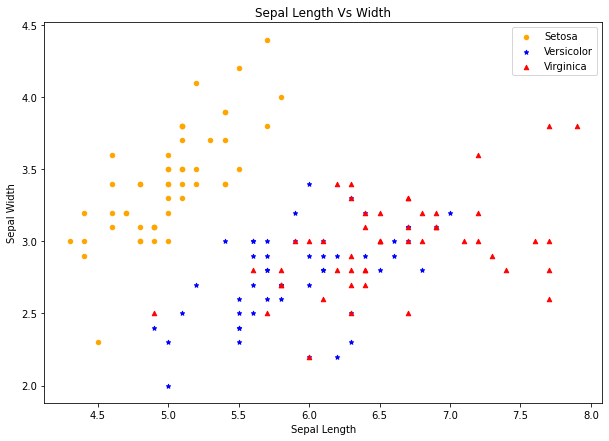

In [8]:
# Graph 1A (matplotlib.pyplot). "Petal Width" vs "Petal Length"
# Conclusion of this graph: "Petal Width" vs "Petal Length" is NOT significant for "Versicolor and Virginica"

ax = plt.axes()
iris[iris.Species == 'Iris-setosa'].plot(kind='scatter', x='SepalLengthCm', y='SepalWidthCm', color='orange', marker="o", label='Setosa', ax=ax)
iris[iris.Species == 'Iris-versicolor'].plot(kind='scatter', x='SepalLengthCm', y='SepalWidthCm', color='blue', marker="*", label='Versicolor', ax=ax)
iris[iris.Species == 'Iris-virginica'].plot(kind='scatter', x='SepalLengthCm', y='SepalWidthCm', color='red', marker="^", label='Virginica', ax=ax)

ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_title('Sepal Length Vs Width')

fig=plt.gcf()
fig.set_size_inches(10, 7)
plt.show()

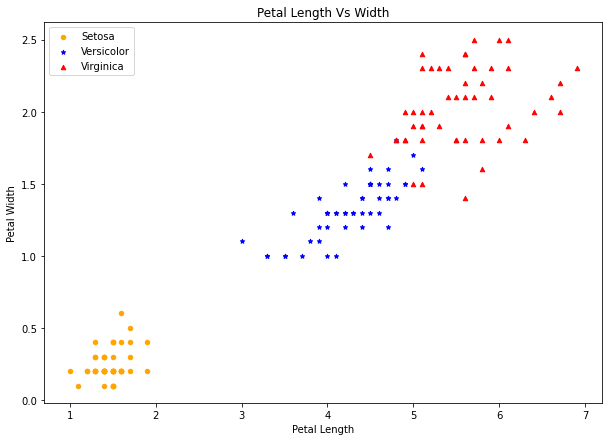

In [9]:
# Graph 1B (matplotlib.pyplot). "Patel Width" vs "Patel Length"
# Conclusion of this graph: "Sepal Width" vs "Sepal Length" IS significant for "Versicolor and Virginica"

ax = plt.axes()
iris[iris.Species == 'Iris-setosa'].plot(kind='scatter', x='PetalLengthCm', y='PetalWidthCm', color='orange', marker="o", label='Setosa', ax=ax)
iris[iris.Species == 'Iris-versicolor'].plot(kind='scatter', x='PetalLengthCm', y='PetalWidthCm', color='blue', marker="*", label='Versicolor', ax=ax)
iris[iris.Species == 'Iris-virginica'].plot(kind='scatter', x='PetalLengthCm', y='PetalWidthCm', color='red', marker="^", label='Virginica', ax=ax)

ax.set_xlabel('Petal Length')
ax.set_ylabel('Petal Width')
ax.set_title('Petal Length Vs Width')

fig=plt.gcf()
fig.set_size_inches(10, 7)

plt.show()
# plt.savefig('Petal_LengthVsWidth.jpeg')

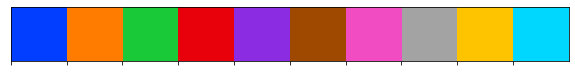

In [10]:
# Test Seaborn colors

sns.palplot(sns.color_palette("bright", 10))
plt.show()

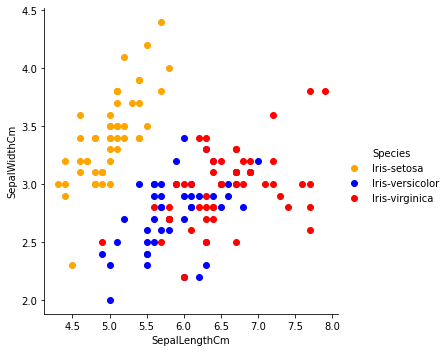

In [11]:
# Graph 2A (Seaborn). "Sepal Width" vs "Sepal Length"
# Conclusion of this graph: "Sepal Width" vs "Sepal Length" is NOT significant for "Versicolor and Virginica"

# markers: https://matplotlib.org/stable/api/markers_api.html
# markers = ["o", "+", "^"]
# sns.markers = markers

colors = ["orange", "blue", "Red"]
sns.set_palette(colors)

graph = sns.FacetGrid(data=iris, hue='Species', height=5)
graph.map(plt.scatter, 'SepalLengthCm', 'SepalWidthCm')
graph.add_legend()

plt.draw()

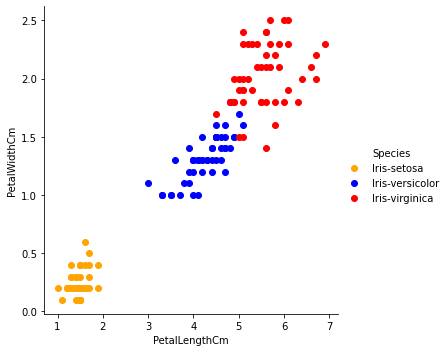

In [12]:
# Graph 2B (Seaborn). "Patel Width" vs "Patel Length"
# Conclusion of this graph: "Sepal Width" vs "Sepal Length" IS significant for "Versicolor and Virginica"

# markers: https://matplotlib.org/stable/api/markers_api.html
# markers = ["o", "+", "^"]
# sns.markers = markers

colors = ["orange", "blue", "Red"]
sns.set_palette(colors)

graph = sns.FacetGrid(data=iris, hue='Species', height=5)
graph.map(plt.scatter, 'PetalLengthCm', 'PetalWidthCm')
graph.add_legend()

plt.draw()

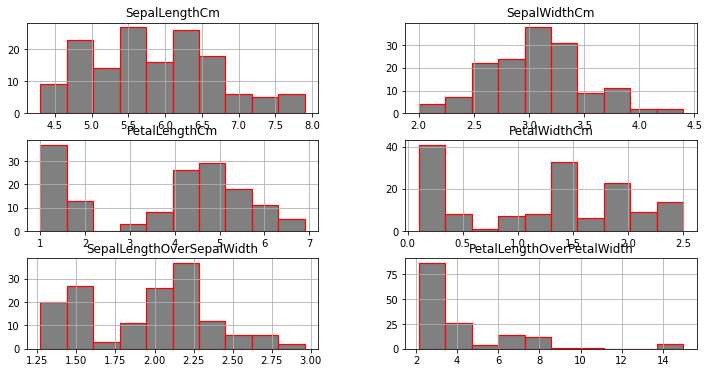

In [13]:
# Graph 5 (matplotlib.pyplot histogram).
# Conclusion of histograms: NOT significance found

iris.hist(color='grey', edgecolor='red', linewidth=1.2)
fig = plt.gcf()
fig.set_size_inches(12,6)
plt.show()

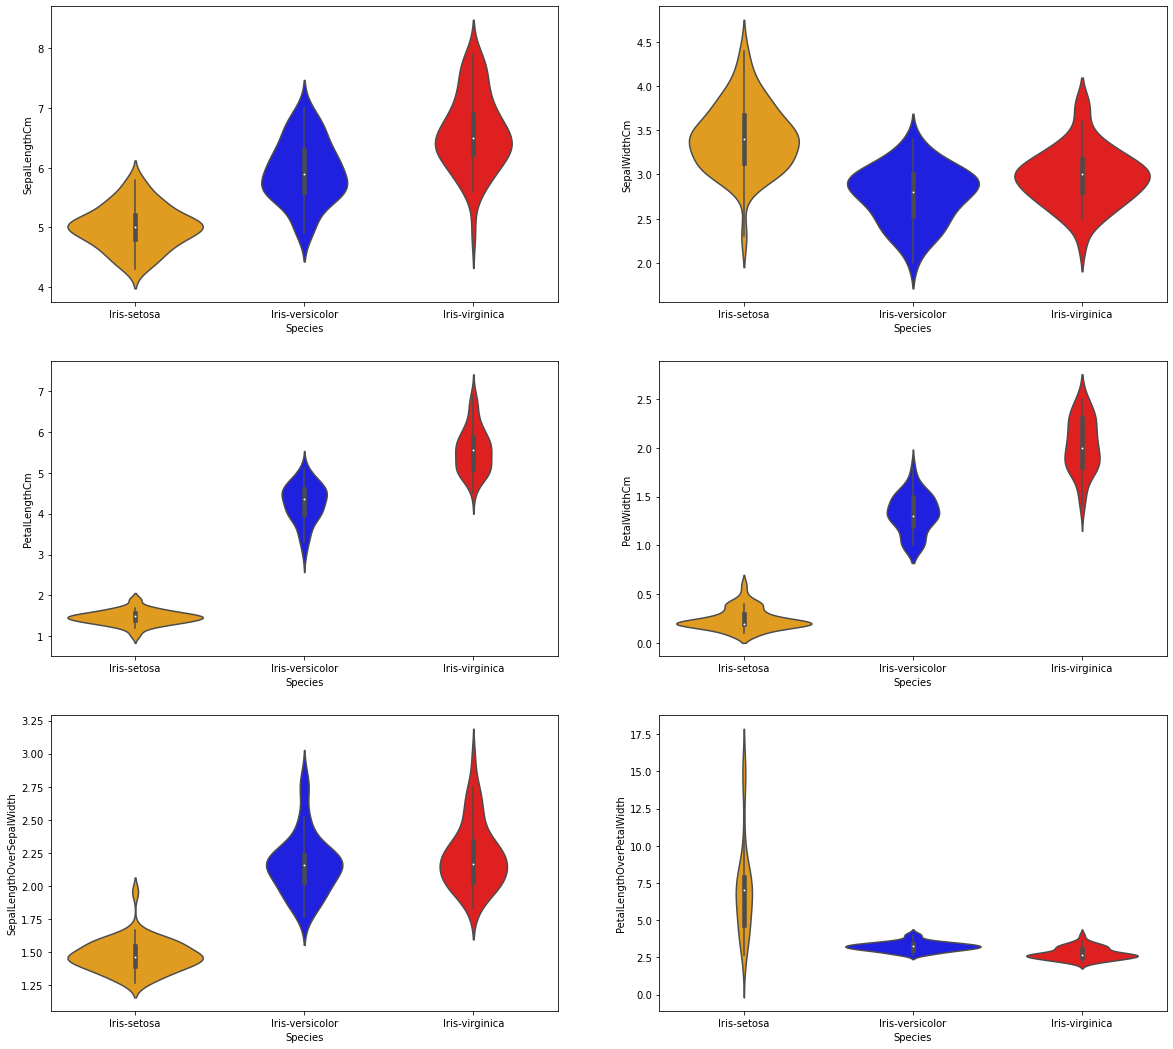

In [14]:
# Graph 7 (seaborn.violinplot).
# Conclusion of histograms: (1) Petal Length and Species are related. (2) Petal Width and Species are related.

from math import ceil

ncols = 2
nrows = ceil(len(iris.columns) / ncols)

idx = 0
for i, col in enumerate(iris.columns):
    if col == 'Species':
        continue
    idx += 1;
    plt.subplot(nrows, ncols, idx)
    sns.violinplot(x='Species', y = col, data=iris)

fig = plt.gcf()
fig.set_size_inches(20, 25)

plt.show()

In [15]:
# Split data to train and test

from sklearn.model_selection import train_test_split

# If random_state (salt for random) is not specified, each time the result is ddifferent.
train, test = train_test_split(iris, test_size=0.3, random_state=20)

print(train.shape)
print(test.shape)

(105, 7)
(45, 7)


In [16]:
X_train = train[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'SepalLengthOverSepalWidth', 'PetalLengthOverPetalWidth']] # taking the training data features
y_train = train.Species # output of the training data

X_test = test[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'SepalLengthOverSepalWidth', 'PetalLengthOverPetalWidth']] # taking test data feature
y_test = test.Species # output value of the test data

In [17]:
print(X_train.head())
print('----------------')
print(y_train.head())

     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
2              4.7           3.2            1.3           0.2   
5              5.4           3.9            1.7           0.4   
49             5.0           3.3            1.4           0.2   
113            5.7           2.5            5.0           2.0   
44             5.1           3.8            1.9           0.4   

     SepalLengthOverSepalWidth  PetalLengthOverPetalWidth  
2                     1.468750                       6.50  
5                     1.384615                       4.25  
49                    1.515152                       7.00  
113                   2.280000                       2.50  
44                    1.342105                       4.75  
----------------
2         Iris-setosa
5         Iris-setosa
49        Iris-setosa
113    Iris-virginica
44        Iris-setosa
Name: Species, dtype: object


In [18]:
# 1. Train SVC

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

model = SVC() # select the svm algorithm
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print('The accuracy of the SVM is: ', accuracy_score(y_pred, y_test))

[[13  0  0]
 [ 0 18  0]
 [ 0  4 10]]
The accuracy of the SVM is:  0.9111111111111111


In [19]:
# 2. Train LogisticRegression

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=100, solver="lbfgs", max_iter=5000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print('The accuracy of LogisticRegression is: ', accuracy_score(y_pred, y_test))

[[13  0  0]
 [ 0 18  0]
 [ 0  4 10]]
The accuracy of LogisticRegression is:  0.9111111111111111


In [20]:
# 3. Train RandomForest

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state = 100)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print('The accuracy of RandomForest is: ', accuracy_score(y_pred, y_test))

[[13  0  0]
 [ 0 18  0]
 [ 0  5  9]]
The accuracy of RandomForest is:  0.8888888888888888
